# Reddit User Churn Prediction Study

## Phase-1: Churn Labeling (Y)

Each user is classified as **churned** (`y = 1`) if they made no posts or comments during the holdout period, and **active** (`y = 0`) otherwise.

**Calibration period:** subreddit creation to July 1, 2025  
**Holdout period:** July 1, 2025 to January 1, 2026 (6 months)

In [57]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROCESSED_DIR = '../data/processed_data/'

# activity records
activity_lp     = pd.read_parquet(PROCESSED_DIR + 'activity_lp.parquet')
activity_loseit = pd.read_parquet(PROCESSED_DIR + 'activity_loseit.parquet')
activity_dep    = pd.read_parquet(PROCESSED_DIR + 'activity_dep.parquet')

# cleaned posts and comments
posts_lp        = pd.read_parquet(PROCESSED_DIR + 'posts_lp.parquet')
posts_loseit    = pd.read_parquet(PROCESSED_DIR + 'posts_loseit.parquet')
posts_dep       = pd.read_parquet(PROCESSED_DIR + 'posts_dep.parquet')

comments_lp     = pd.read_parquet(PROCESSED_DIR + 'comments_lp.parquet')
comments_loseit = pd.read_parquet(PROCESSED_DIR + 'comments_loseit.parquet')
comments_dep    = pd.read_parquet(PROCESSED_DIR + 'comments_dep.parquet')

# user stats
user_stats_lp     = pd.read_parquet(PROCESSED_DIR + 'user_stats_lp.parquet')
user_stats_loseit = pd.read_parquet(PROCESSED_DIR + 'user_stats_loseit.parquet')
user_stats_dep    = pd.read_parquet(PROCESSED_DIR + 'user_stats_dep.parquet')

# reply edge lists
edges_lp        = pd.read_parquet(PROCESSED_DIR + 'edges_lp.parquet')
edges_loseit    = pd.read_parquet(PROCESSED_DIR + 'edges_loseit.parquet')
edges_dep       = pd.read_parquet(PROCESSED_DIR + 'edges_dep.parquet')

print("all DataFrames loaded")

all DataFrames loaded


In [59]:
HOLDOUT_START = pd.Timestamp('2025-07-01', tz='UTC')
OBS_END       = pd.Timestamp('2026-01-01', tz='UTC')

print(f"calibration ends : {HOLDOUT_START.date()}")
print(f"holdout period   : {HOLDOUT_START.date()} to {OBS_END.date()}")

calibration ends : 2025-07-01
holdout period   : 2025-07-01 to 2026-01-01


**Note on churn labeling method**

The BG/NBD (Beta Geometric Negative Binomial Distribution) model was initially chosen for churn labeling. It estimates each user's posting rate and dropout probability from three inputs: frequency, recency, and T (total observation time). However, the model failed to converge on all three subreddits. The most likely cause is the wide range of T values in the data: because the subreddits span over a decade, users' observation periods range from a few weeks to more than 15 years. This produces numerical instability in the likelihood optimizer. Multiple configurations were tested, including different penalization coefficients, time unit rescaling, randomization, and alternative starting values, but none achieved convergence.

As a result, churn is defined using the holdout period directly. A user is classified as churned if they made no posts or comments during the six-month holdout window (July 1 to December 31, 2025). This approach is standard in non-contractual churn research and does not require any model fitting.

**Limitation:** this definition may misclassify users who are genuinely active but post infrequently. A user who posts only a few times per year could have no activity during a six-month window without having permanently left the community. The BG/NBD model would have accounted for this by estimating each user's individual posting rhythm, but that adjustment is not feasible here.

### Subreddit-1: learnprogramming

In [60]:
# split activity into calibration and holdout periods
cal_lp = activity_lp[activity_lp['created_utc'] < HOLDOUT_START].copy()
hld_lp = activity_lp[activity_lp['created_utc'] >= HOLDOUT_START].copy()

print(f"calibration records: {len(cal_lp):,}")
print(f"holdout records:     {len(hld_lp):,}")

calibration records: 4,374,119
holdout records:     160,232


In [61]:
# compute BG/NBD inputs from calibration period
bgnbd_cal_lp = cal_lp.groupby('author').agg(
    n_cal      = ('created_utc', 'count'),
    first_post = ('created_utc', 'min'),
    last_cal   = ('created_utc', 'max')
).reset_index()

bgnbd_cal_lp['T_cal']         = (HOLDOUT_START - bgnbd_cal_lp['first_post']).dt.days / 7
bgnbd_cal_lp['recency_cal']   = (bgnbd_cal_lp['last_cal'] - bgnbd_cal_lp['first_post']).dt.days / 7
bgnbd_cal_lp['frequency_cal'] = bgnbd_cal_lp['n_cal'] - 1

bgnbd_cal_lp = bgnbd_cal_lp[bgnbd_cal_lp['T_cal'] > 0].reset_index(drop=True)

print(f"calibration users: {len(bgnbd_cal_lp):,}")
bgnbd_cal_lp[['frequency_cal', 'recency_cal', 'T_cal']].describe().round(2)

calibration users: 573,196


,frequency_cal,recency_cal,T_cal
count,573196.00,573196.00,573196.00
mean,6.63,30.38,290.59
std,103.20,79.82,194.73
min,0.00,0.00,0.14
25%,0.00,0.00,132.43
50%,1.00,0.00,256.14
75%,3.00,13.00,434.57
max,36527.00,812.86,822.57


In [62]:
# check who was active during holdout
holdout_users_lp = set(hld_lp['author'].unique())
bgnbd_cal_lp['active_holdout'] = bgnbd_cal_lp['author'].isin(holdout_users_lp).astype(int)

print(f"active in holdout:   {bgnbd_cal_lp['active_holdout'].sum():,}  ({bgnbd_cal_lp['active_holdout'].mean()*100:.1f}%)")
print(f"inactive in holdout: {(bgnbd_cal_lp['active_holdout']==0).sum():,}  ({(1-bgnbd_cal_lp['active_holdout'].mean())*100:.1f}%)")

active in holdout:   12,999  (2.3%)
inactive in holdout: 560,197  (97.7%)


In [63]:
# churn label: no activity during holdout = churned
bgnbd_cal_lp['churned'] = (bgnbd_cal_lp['active_holdout'] == 0).astype(int)

n_total_lp   = len(bgnbd_cal_lp)
n_churned_lp = bgnbd_cal_lp['churned'].sum()

print(f"r/learnprogramming")
print(f"  total  : {n_total_lp:,}")
print(f"  churned: {n_churned_lp:,}  ({n_churned_lp/n_total_lp*100:.1f}%)")
print(f"  active : {n_total_lp - n_churned_lp:,}  ({(n_total_lp - n_churned_lp)/n_total_lp*100:.1f}%)")

r/learnprogramming
  total  : 573,196
  churned: 560,197  (97.7%)
  active : 12,999  (2.3%)


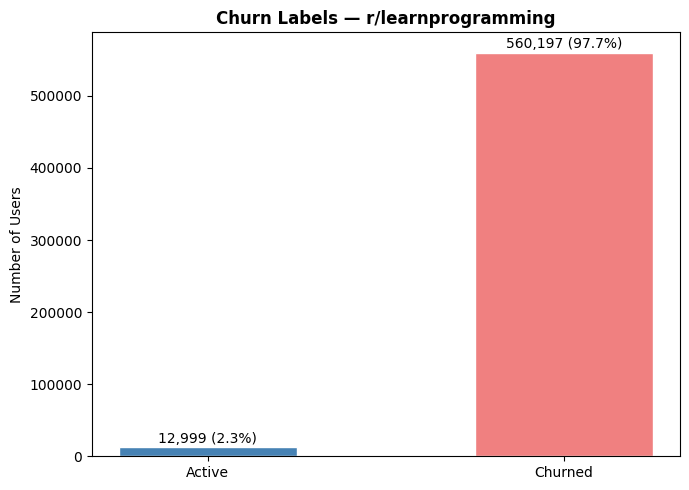

In [64]:
labels = ['Active', 'Churned']
sizes  = [n_total_lp - n_churned_lp, n_churned_lp]
colors = ['steelblue', 'lightcoral']

plt.figure(figsize=(7, 5))
plt.bar(labels, sizes, color=colors, edgecolor='white', width=0.5)
plt.title('Churn Labels — r/learnprogramming', fontweight='bold')
plt.ylabel('Number of Users')
for i, v in enumerate(sizes):
    plt.text(i, v + n_total_lp * 0.01, f'{v:,} ({v/n_total_lp*100:.1f}%)', ha='center')
plt.tight_layout()
plt.show()

In [65]:
bgnbd_cal_lp.to_parquet('../data/processed_data/churn_lp.parquet', index=False)
print("saved churn_lp.parquet")

saved churn_lp.parquet


### Subreddit-2: loseit

In [66]:
# split activity into calibration and holdout periods
cal_loseit = activity_loseit[activity_loseit['created_utc'] < HOLDOUT_START].copy()
hld_loseit = activity_loseit[activity_loseit['created_utc'] >= HOLDOUT_START].copy()

print(f"calibration records: {len(cal_loseit):,}")
print(f"holdout records:     {len(hld_loseit):,}")

calibration records: 7,910,110
holdout records:     337,542


In [67]:
# compute BG/NBD inputs from calibration period
bgnbd_cal_loseit = cal_loseit.groupby('author').agg(
    n_cal      = ('created_utc', 'count'),
    first_post = ('created_utc', 'min'),
    last_cal   = ('created_utc', 'max')
).reset_index()

bgnbd_cal_loseit['T_cal']         = (HOLDOUT_START - bgnbd_cal_loseit['first_post']).dt.days / 7
bgnbd_cal_loseit['recency_cal']   = (bgnbd_cal_loseit['last_cal'] - bgnbd_cal_loseit['first_post']).dt.days / 7
bgnbd_cal_loseit['frequency_cal'] = bgnbd_cal_loseit['n_cal'] - 1

bgnbd_cal_loseit = bgnbd_cal_loseit[bgnbd_cal_loseit['T_cal'] > 0].reset_index(drop=True)

print(f"calibration users: {len(bgnbd_cal_loseit):,}")
bgnbd_cal_loseit[['frequency_cal', 'recency_cal', 'T_cal']].describe().round(2)

calibration users: 761,112


,frequency_cal,recency_cal,T_cal
count,761112.00,761112.00,761112.00
mean,9.39,38.57,310.48
std,108.17,92.01,205.32
min,0.00,0.00,0.14
25%,0.00,0.00,135.00
50%,1.00,0.00,285.00
75%,5.00,24.86,450.86
max,60107.00,769.14,778.57


In [68]:
# check who was active during holdout
holdout_users_loseit = set(hld_loseit['author'].unique())
bgnbd_cal_loseit['active_holdout'] = bgnbd_cal_loseit['author'].isin(holdout_users_loseit).astype(int)

print(f"active in holdout:   {bgnbd_cal_loseit['active_holdout'].sum():,}  ({bgnbd_cal_loseit['active_holdout'].mean()*100:.1f}%)")
print(f"inactive in holdout: {(bgnbd_cal_loseit['active_holdout']==0).sum():,}  ({(1-bgnbd_cal_loseit['active_holdout'].mean())*100:.1f}%)")

active in holdout:   26,465  (3.5%)
inactive in holdout: 734,647  (96.5%)


In [69]:
bgnbd_cal_loseit['churned'] = (bgnbd_cal_loseit['active_holdout'] == 0).astype(int)

n_total_loseit   = len(bgnbd_cal_loseit)
n_churned_loseit = bgnbd_cal_loseit['churned'].sum()

print(f"r/loseit")
print(f"  total  : {n_total_loseit:,}")
print(f"  churned: {n_churned_loseit:,}  ({n_churned_loseit/n_total_loseit*100:.1f}%)")
print(f"  active : {n_total_loseit - n_churned_loseit:,}  ({(n_total_loseit - n_churned_loseit)/n_total_loseit*100:.1f}%)")

r/loseit
  total  : 761,112
  churned: 734,647  (96.5%)
  active : 26,465  (3.5%)


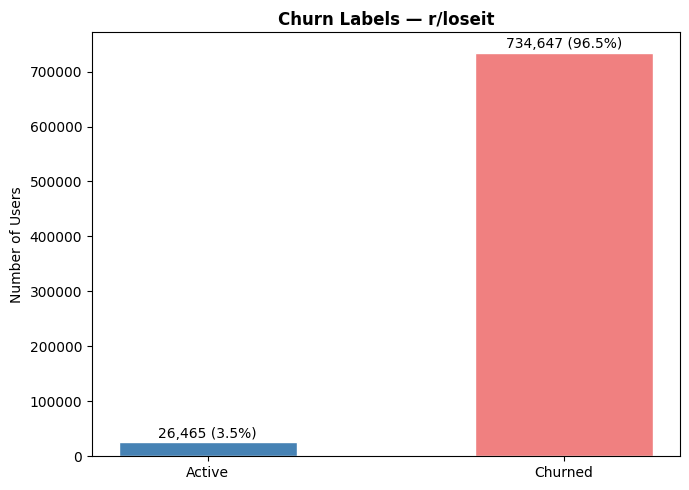

In [70]:
labels = ['Active', 'Churned']
sizes  = [n_total_loseit - n_churned_loseit, n_churned_loseit]
colors = ['steelblue', 'lightcoral']

plt.figure(figsize=(7, 5))
plt.bar(labels, sizes, color=colors, edgecolor='white', width=0.5)
plt.title('Churn Labels — r/loseit', fontweight='bold')
plt.ylabel('Number of Users')
for i, v in enumerate(sizes):
    plt.text(i, v + n_total_loseit * 0.01, f'{v:,} ({v/n_total_loseit*100:.1f}%)', ha='center')
plt.tight_layout()
plt.show()

In [71]:
bgnbd_cal_loseit.to_parquet('../data/processed_data/churn_loseit.parquet', index=False)
print("saved churn_loseit.parquet")

saved churn_loseit.parquet


### Subreddit-3: depression

In [72]:
# split activity into calibration and holdout periods
cal_dep = activity_dep[activity_dep['created_utc'] < HOLDOUT_START].copy()
hld_dep = activity_dep[activity_dep['created_utc'] >= HOLDOUT_START].copy()

print(f"calibration records: {len(cal_dep):,}")
print(f"holdout records:     {len(hld_dep):,}")

calibration records: 6,410,536
holdout records:     243,495


In [73]:
# compute BG/NBD inputs from calibration period
bgnbd_cal_dep = cal_dep.groupby('author').agg(
    n_cal      = ('created_utc', 'count'),
    first_post = ('created_utc', 'min'),
    last_cal   = ('created_utc', 'max')
).reset_index()

bgnbd_cal_dep['T_cal']         = (HOLDOUT_START - bgnbd_cal_dep['first_post']).dt.days / 7
bgnbd_cal_dep['recency_cal']   = (bgnbd_cal_dep['last_cal'] - bgnbd_cal_dep['first_post']).dt.days / 7
bgnbd_cal_dep['frequency_cal'] = bgnbd_cal_dep['n_cal'] - 1

bgnbd_cal_dep = bgnbd_cal_dep[bgnbd_cal_dep['T_cal'] > 0].reset_index(drop=True)

print(f"calibration users: {len(bgnbd_cal_dep):,}")
bgnbd_cal_dep[['frequency_cal', 'recency_cal', 'T_cal']].describe().round(2)

calibration users: 1,171,362


,frequency_cal,recency_cal,T_cal
count,1171362.00,1171362.00,1171362.00
mean,4.47,18.52,294.43
std,30.28,55.14,182.63
min,0.00,0.00,0.14
25%,0.00,0.00,145.57
50%,1.00,0.00,287.29
75%,3.00,4.57,418.57
max,16593.00,827.86,860.57


In [74]:
# check who was active during holdout
holdout_users_dep = set(hld_dep['author'].unique())
bgnbd_cal_dep['active_holdout'] = bgnbd_cal_dep['author'].isin(holdout_users_dep).astype(int)

print(f"active in holdout:   {bgnbd_cal_dep['active_holdout'].sum():,}  ({bgnbd_cal_dep['active_holdout'].mean()*100:.1f}%)")
print(f"inactive in holdout: {(bgnbd_cal_dep['active_holdout']==0).sum():,}  ({(1-bgnbd_cal_dep['active_holdout'].mean())*100:.1f}%)")

active in holdout:   21,070  (1.8%)
inactive in holdout: 1,150,292  (98.2%)


In [75]:
bgnbd_cal_dep['churned'] = (bgnbd_cal_dep['active_holdout'] == 0).astype(int)

n_total_dep   = len(bgnbd_cal_dep)
n_churned_dep = bgnbd_cal_dep['churned'].sum()

print(f"r/depression")
print(f"  total  : {n_total_dep:,}")
print(f"  churned: {n_churned_dep:,}  ({n_churned_dep/n_total_dep*100:.1f}%)")
print(f"  active : {n_total_dep - n_churned_dep:,}  ({(n_total_dep - n_churned_dep)/n_total_dep*100:.1f}%)")

r/depression
  total  : 1,171,362
  churned: 1,150,292  (98.2%)
  active : 21,070  (1.8%)


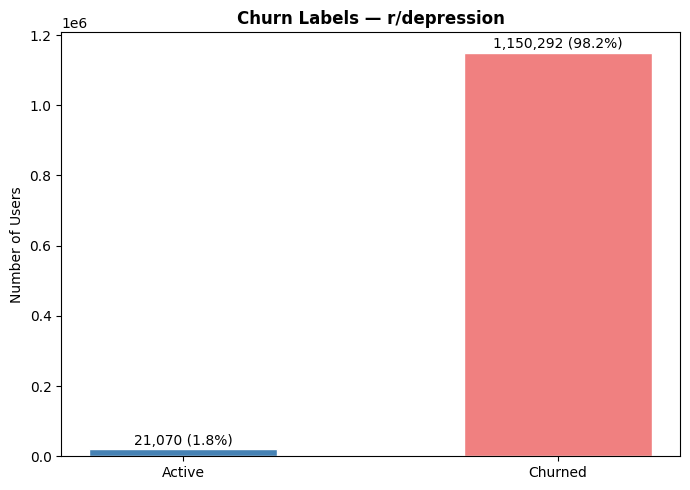

In [76]:
labels = ['Active', 'Churned']
sizes  = [n_total_dep - n_churned_dep, n_churned_dep]
colors = ['steelblue', 'lightcoral']

plt.figure(figsize=(7, 5))
plt.bar(labels, sizes, color=colors, edgecolor='white', width=0.5)
plt.title('Churn Labels — r/depression', fontweight='bold')
plt.ylabel('Number of Users')
for i, v in enumerate(sizes):
    plt.text(i, v + n_total_dep * 0.01, f'{v:,} ({v/n_total_dep*100:.1f}%)', ha='center')
plt.tight_layout()
plt.show()

In [77]:
bgnbd_cal_dep.to_parquet('../data/processed_data/churn_dep.parquet', index=False)
print("saved churn_dep.parquet")

saved churn_dep.parquet


### Summary

In [78]:
# churn label summary across all three subreddits
summary = pd.DataFrame({
    'Subreddit':     ['r/learnprogramming', 'r/loseit', 'r/depression'],
    'Total users':   [n_total_lp,   n_total_loseit,   n_total_dep],
    'Churned':       [n_churned_lp, n_churned_loseit, n_churned_dep],
    'Active':        [n_total_lp - n_churned_lp,
                      n_total_loseit - n_churned_loseit,
                      n_total_dep - n_churned_dep],
    'Churn rate (%)': [round(n_churned_lp/n_total_lp*100, 1),
                       round(n_churned_loseit/n_total_loseit*100, 1),
                       round(n_churned_dep/n_total_dep*100, 1)]
})
summary

,Subreddit,Total users,Churned,Active,Churn rate (%)
0,r/learnprogramming,573196,560197,12999,97.7
1,r/loseit,761112,734647,26465,96.5
2,r/depression,1171362,1150292,21070,98.2


## Phase-2: Feature Engineering (X)

All features are computed from the **calibration period only** (subreddit creation to July 1, 2025). The output is one row per user with NLP and network features as columns, merged with the churn label from Phase 1.

### Subreddit-1: learnprogramming


#### Part-1: NLP features

| Feature | Description |
|---|---|
| `sentiment_mean` | mean VADER compound score across all posts and comments |
| `lexical_diversity` | type-token ratio (unique words / total words) |
| `avg_post_len` | mean word count per post (0 if user never posted) |
| `avg_comment_len` | mean word count per comment |
| `post_comment_ratio` | posts / (posts + comments) |

In [80]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import numpy as np

sid = SentimentIntensityAnalyzer()

In [81]:
# filter to calibration period and qualifying users only
qual_users_lp = set(bgnbd_cal_lp['author'])

cal_posts_lp_nlp = posts_lp[
    (posts_lp['created_utc'] < HOLDOUT_START) &
    (posts_lp['author'].isin(qual_users_lp))
].copy()

cal_comments_lp_nlp = comments_lp[
    (comments_lp['created_utc'] < HOLDOUT_START) &
    (comments_lp['author'].isin(qual_users_lp))
].copy()

print(f"calibration posts:    {len(cal_posts_lp_nlp):,}")
print(f"calibration comments: {len(cal_comments_lp_nlp):,}")

calibration posts:    498,500
calibration comments: 3,875,378


498,500 posts and 3,875,378 comments fall within the calibration period for qualifying users.

In [82]:
# extract text columns and compute VADER compound score
text_col = 'selftext' if 'selftext' in cal_posts_lp_nlp.columns else 'body'
cal_posts_lp_nlp['text'] = cal_posts_lp_nlp[text_col].fillna('').str.strip()
cal_comments_lp_nlp['text'] = cal_comments_lp_nlp['body'].fillna('').str.strip()

cal_posts_lp_nlp['sentiment'] = cal_posts_lp_nlp['text'].apply(
    lambda x: sid.polarity_scores(x)['compound'] if x else np.nan
)
cal_comments_lp_nlp['sentiment'] = cal_comments_lp_nlp['text'].apply(
    lambda x: sid.polarity_scores(x)['compound'] if x else np.nan
)

print("VADER scoring done")

VADER scoring done


VADER assigns a compound sentiment score between -1 (most negative) and +1 (most positive) to each piece of text. Scoring was applied to all posts and comments separately so that they can be combined for user-level analysis in the next step.

In [87]:
# combine posts and comments for sentiment features
all_text_lp = pd.concat([
    cal_posts_lp_nlp[['author', 'created_utc', 'sentiment']],
    cal_comments_lp_nlp[['author', 'created_utc', 'sentiment']]
]).dropna(subset=['sentiment'])

# mean sentiment per user
sentiment_mean_lp = all_text_lp.groupby('author')['sentiment'].mean().reset_index()
sentiment_mean_lp.columns = ['author', 'sentiment_mean']

print(f"sentiment_mean done: {len(sentiment_mean_lp):,} users")

sentiment_mean done: 553,081 users


Sentiment scores were computed for 553,081 out of 573,196 qualifying users. The remaining 20,115 users had no text content during the calibration period and were later filled with the column median in the assembly step.

In [88]:
# lexical diversity: unique words / total words (per user, across all text)
all_text_combined_lp = pd.concat([
    cal_posts_lp_nlp[['author', 'text']],
    cal_comments_lp_nlp[['author', 'text']]
])

def ttr(texts):
    words = ' '.join(texts).lower().split()
    return len(set(words)) / len(words) if words else np.nan

lex_div_lp = (
    all_text_combined_lp.groupby('author')['text']
    .apply(list).apply(ttr).reset_index()
)
lex_div_lp.columns = ['author', 'lexical_diversity']

# average post and comment length (word count)
cal_posts_lp_nlp['word_count'] = cal_posts_lp_nlp['text'].str.split().str.len()
cal_comments_lp_nlp['word_count'] = cal_comments_lp_nlp['text'].str.split().str.len()

avg_post_len_lp    = cal_posts_lp_nlp.groupby('author')['word_count'].mean().reset_index()
avg_post_len_lp.columns = ['author', 'avg_post_len']

avg_comment_len_lp = cal_comments_lp_nlp.groupby('author')['word_count'].mean().reset_index()
avg_comment_len_lp.columns = ['author', 'avg_comment_len']

# post-to-comment ratio
n_posts_lp    = cal_posts_lp_nlp.groupby('author').size().reset_index(name='n_posts')
n_comments_lp = cal_comments_lp_nlp.groupby('author').size().reset_index(name='n_comments')
ratio_lp = n_posts_lp.merge(n_comments_lp, on='author', how='outer').fillna(0)
ratio_lp['post_comment_ratio'] = ratio_lp['n_posts'] / (ratio_lp['n_posts'] + ratio_lp['n_comments'])

print("lexical diversity, lengths, ratio done")

lexical diversity, lengths, ratio done


Lexical diversity, post length, comment length, and the post-comment ratio were computed for all qualifying users. Users with no posts received an `avg_post_len` of 0, and users with no comments received an `avg_comment_len` of 0.

In [94]:
# assemble NLP feature table
features_nlp_lp = bgnbd_cal_lp[['author', 'churned']].copy()

for df, key in [
    (sentiment_mean_lp,  'author'),
    (lex_div_lp,         'author'),
    (avg_post_len_lp,    'author'),
    (avg_comment_len_lp, 'author'),
    (ratio_lp[['author', 'post_comment_ratio']], 'author')
]:
    features_nlp_lp = features_nlp_lp.merge(df, on=key, how='left')

# users with no posts: fill avg_post_len with 0
features_nlp_lp['avg_post_len']      = features_nlp_lp['avg_post_len'].fillna(0)
features_nlp_lp['avg_comment_len']   = features_nlp_lp['avg_comment_len'].fillna(0)
features_nlp_lp['sentiment_mean']    = features_nlp_lp['sentiment_mean'].fillna(features_nlp_lp['sentiment_mean'].median())
features_nlp_lp['lexical_diversity'] = features_nlp_lp['lexical_diversity'].fillna(features_nlp_lp['lexical_diversity'].median())

print(features_nlp_lp.shape)
print(features_nlp_lp.isnull().sum())
features_nlp_lp.head()

(573196, 7)
author                0
churned               0
sentiment_mean        0
lexical_diversity     0
avg_post_len          0
avg_comment_len       0
post_comment_ratio    0
dtype: int64


,author,churned,sentiment_mean,lexical_diversity,avg_post_len,avg_comment_len,post_comment_ratio
0,-------------------7,0,0.661975,0.714976,0.0,51.75,0.0
1,-------___---------,1,0.419900,1.000000,0.0,6.00,0.0
2,------Fire------,1,0.696250,0.725352,107.0,35.00,0.5
3,------_-_-_------,1,0.000000,1.000000,0.0,1.00,0.0
4,------what------,1,0.906000,0.923077,39.0,0.00,1.0


The assembled feature table has 573,196 rows and 7 columns. After imputation, no missing values remain across any feature, so the table is ready for model training.

**Missing value handling:**

- `avg_post_len`, `avg_comment_len`: filled with 0. Users with no posts or no comments genuinely have a length of zero.
- `sentiment_mean`, `lexical_diversity`: filled with the column median. These users had no text content during the calibration period, so their sentiment and lexical diversity cannot be computed. Zero is not used because a VADER score of 0 indicates neutral sentiment, which would be indistinguishable from a true neutral user.

In [95]:
features_nlp_lp.to_parquet('../data/processed_data/features_nlp_lp.parquet', index=False)
print("saved features_nlp_lp.parquet")

saved features_nlp_lp.parquet


**Interpretation**

- Most users have `post_comment_ratio` close to 0, indicating r/learnprogramming is comment-dominant; a shift toward fewer or shorter contributions — captured by `avg_post_len` and `avg_comment_len` — may reflect reduced engagement before churning.
- Users with very limited calibration-period text tend to have `lexical_diversity` close to 1.0, since every word is nearly unique when the corpus is small; these minimally active users may be over-represented among churned users.

#### Part-2: Network features

| Feature | Description |
|---|---|
| `out_degree` | number of unique users replied to |
| `in_degree` | number of unique users who replied to this user |
| `clustering_coef` | local clustering coefficient (undirected graph) |
| `k_core` | maximum k-core the user belongs to |
| `community_size` | size of the Louvain community the user belongs to |
| `within_community_ratio` | share of interactions within vs. outside the community |
| `unique_partners` | total unique users interacted with during calibration |
| `interaction_freq` | total number of interactions during calibration |
| `unique_partners_slope` | monthly trend in unique partners (slope; 0 if < 2 months) |
| `interaction_freq_slope` | monthly trend in interaction count (slope; 0 if < 2 months) |

In [96]:
import networkx as nx

# rebuild calibration-period edges with timestamps from comment reply structure
cal_cmt_lp = comments_lp[comments_lp['created_utc'] < HOLDOUT_START].copy()
replies_lp = cal_cmt_lp[cal_cmt_lp['parent_id'].str.startswith('t1_')].copy()
replies_lp['parent_comment_id'] = replies_lp['parent_id'].str[3:]

id_author_lp = (comments_lp[['id', 'author']]
                .drop_duplicates('id').set_index('id')['author'])
replies_lp['parent_author'] = replies_lp['parent_comment_id'].map(id_author_lp)
replies_lp = replies_lp.dropna(subset=['parent_author'])

qual_users_lp = set(bgnbd_cal_lp['author'])
cal_edges_timed_lp = replies_lp[
    (replies_lp['author'].isin(qual_users_lp)) &
    (replies_lp['parent_author'].isin(qual_users_lp)) &
    (replies_lp['author'] != replies_lp['parent_author'])
][['author', 'parent_author', 'created_utc']].reset_index(drop=True)

print(f"calibration edges: {len(cal_edges_timed_lp):,}")

calibration edges: 1,937,017


1,937,017 directed edges were identified from comment reply relationships during the calibration period, after removing self-loops and restricting to qualifying users on both ends.

In [97]:
# directed graph for in/out degree
G_dir_lp = nx.from_pandas_edgelist(
    cal_edges_timed_lp, 'author', 'parent_author',
    create_using=nx.DiGraph()
)
G_und_lp = G_dir_lp.to_undirected()

out_deg_lp = pd.Series(dict(G_dir_lp.out_degree()), name='out_degree').reset_index()
out_deg_lp.columns = ['author', 'out_degree']

in_deg_lp = pd.Series(dict(G_dir_lp.in_degree()), name='in_degree').reset_index()
in_deg_lp.columns = ['author', 'in_degree']

clustering_lp = pd.Series(nx.clustering(G_und_lp), name='clustering_coef').reset_index()
clustering_lp.columns = ['author', 'clustering_coef']

kcore_lp = pd.Series(nx.core_number(G_und_lp), name='k_core').reset_index()
kcore_lp.columns = ['author', 'k_core']

print("static features done")

static features done


Out-degree, in-degree, local clustering coefficient, and k-core number were computed for all nodes in the reply graph. Users who never appeared in the reply graph (i.e., they never replied to or received replies from other qualifying users) will receive 0 for all degree-based features in the assembly step.

In [98]:
# Louvain community detection (may take a few minutes on large graphs)
communities_lp = nx.community.louvain_communities(G_und_lp, seed=42)

community_map_lp = {}
for cid, comm in enumerate(communities_lp):
    for node in comm:
        community_map_lp[node] = cid

comm_size_map_lp = {cid: len(comm) for cid, comm in enumerate(communities_lp)}

community_df_lp = pd.DataFrame({
    'author':         list(community_map_lp.keys()),
    'community_id':   list(community_map_lp.values())
})
community_df_lp['community_size'] = community_df_lp['community_id'].map(comm_size_map_lp)

# within-community ratio (vectorized)
edges_comm_lp = cal_edges_timed_lp[['author', 'parent_author']].copy()
edges_comm_lp['src_comm'] = edges_comm_lp['author'].map(community_map_lp)
edges_comm_lp['dst_comm'] = edges_comm_lp['parent_author'].map(community_map_lp)
edges_comm_lp['within'] = (edges_comm_lp['src_comm'] == edges_comm_lp['dst_comm']).astype(int)
within_ratio_lp = (edges_comm_lp.groupby('author')['within']
                   .mean().reset_index()
                   .rename(columns={'within': 'within_community_ratio'}))

print(f"community detection done: {len(communities_lp):,} communities")

community detection done: 5,165 communities


Louvain community detection identified 5,165 communities within the r/learnprogramming reply graph. The within-community ratio measures what share of a user's interactions stayed within their detected community, capturing whether a user is a core participant in a local group or more of a peripheral, cross-community connector.

In [99]:
# monthly interaction counts per user
cal_edges_timed_lp['month'] = cal_edges_timed_lp['created_utc'].dt.to_period('M')
monthly_lp = (cal_edges_timed_lp
    .groupby(['author', 'month'])
    .agg(unique_partners=('parent_author', 'nunique'),
         interaction_count=('parent_author', 'count'))
    .reset_index()
)
monthly_lp = monthly_lp.sort_values(['author', 'month'])
monthly_lp['month_num'] = monthly_lp.groupby('author').cumcount()

def slope(g, col):
    if len(g) < 2:
        return np.nan
    return np.polyfit(g['month_num'], g[col], 1)[0]

partners_slope_lp = (monthly_lp.groupby('author')
    .apply(lambda g: slope(g, 'unique_partners'))
    .reset_index().rename(columns={0: 'unique_partners_slope'}))

freq_slope_lp = (monthly_lp.groupby('author')
    .apply(lambda g: slope(g, 'interaction_count'))
    .reset_index().rename(columns={0: 'interaction_freq_slope'}))

total_partners_lp = (cal_edges_timed_lp.groupby('author')['parent_author']
    .nunique().reset_index().rename(columns={'parent_author': 'unique_partners'}))

total_freq_lp = (cal_edges_timed_lp.groupby('author')
    .size().reset_index(name='interaction_freq'))

print("temporal features done")

/var/folders/6z/l1qqp42x5wb574gxqs26g6zw0000gn/T/ipykernel_44745/493531001.py:2: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  cal_edges_timed_lp['month'] = cal_edges_timed_lp['created_utc'].dt.to_period('M')


temporal features done


Monthly interaction counts were aggregated per user to capture how their network activity changed over time.

In [100]:
features_net_lp = bgnbd_cal_lp[['author', 'churned']].copy()

for df in [
    out_deg_lp, in_deg_lp, clustering_lp, kcore_lp,
    community_df_lp[['author', 'community_size']],
    within_ratio_lp, total_partners_lp, total_freq_lp,
    partners_slope_lp, freq_slope_lp
]:
    features_net_lp = features_net_lp.merge(df, on='author', how='left')

# users with no interactions: degree/count features → 0
for col in ['out_degree', 'in_degree', 'clustering_coef', 'k_core',
            'unique_partners', 'interaction_freq']:
    features_net_lp[col] = features_net_lp[col].fillna(0)

# slopes → 0 (no trend detected)
features_net_lp['unique_partners_slope']  = features_net_lp['unique_partners_slope'].fillna(0)
features_net_lp['interaction_freq_slope'] = features_net_lp['interaction_freq_slope'].fillna(0)

# community: isolated users get size=1, ratio=median
features_net_lp['community_size'] = features_net_lp['community_size'].fillna(1)
features_net_lp['within_community_ratio'] = features_net_lp['within_community_ratio'].fillna(
    features_net_lp['within_community_ratio'].median()
)

print(features_net_lp.shape)
print(features_net_lp.isnull().sum())
features_net_lp.head()

(573196, 12)
author                    0
churned                   0
out_degree                0
in_degree                 0
clustering_coef           0
k_core                    0
community_size            0
within_community_ratio    0
unique_partners           0
interaction_freq          0
unique_partners_slope     0
interaction_freq_slope    0
dtype: int64


,author,churned,out_degree,in_degree,clustering_coef,k_core,community_size,within_community_ratio,unique_partners,interaction_freq,unique_partners_slope,interaction_freq_slope
0,-------------------7,0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
1,-------___---------,1,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
2,------Fire------,1,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
3,------_-_-_------,1,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
4,------what------,1,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0


The assembled network feature table contains 573,196 rows and 12 columns with no missing values. The large share of users with zero degree features reflects the common Reddit pattern where many users post or comment without directly replying to other users, making them structurally isolated in the reply graph.

In [101]:
features_net_lp.to_parquet('../data/processed_data/features_net_lp.parquet', index=False)
print("saved features_net_lp.parquet")

saved features_net_lp.parquet


**Interpretation**
- The reply graph contains 1,937,017 directed edges, yet a large share of users have zero in-degree and out-degree, reflecting a community where many users engage through posts alone without sustained reply exchanges.
- Users with higher degree, k-core, and within-community ratio are structurally embedded in the network; users at the periphery (low degree, k-core = 1, small community size) are less connected and are expected to be more likely to churn.

### Subreddit-2: loseit

#### Part-1: NLP features

In [104]:
cal_posts_loseit_nlp = posts_loseit[
    (posts_loseit['created_utc'] < HOLDOUT_START) &
    (posts_loseit['author'].isin(set(bgnbd_cal_loseit['author'])))
].copy()
cal_comments_loseit_nlp = comments_loseit[
    (comments_loseit['created_utc'] < HOLDOUT_START) &
    (comments_loseit['author'].isin(set(bgnbd_cal_loseit['author'])))
].copy()
print(f"calibration posts:    {len(cal_posts_loseit_nlp):,}")
print(f"calibration comments: {len(cal_comments_loseit_nlp):,}")

calibration posts:    495,380
calibration comments: 7,414,295


Calibration-period posts and comments were filtered to qualifying users in r/loseit. Only records before July 1, 2025 are retained to prevent holdout-period data from leaking into the feature computation.

In [105]:
text_col = 'selftext' if 'selftext' in cal_posts_loseit_nlp.columns else 'body'
cal_posts_loseit_nlp['text'] = cal_posts_loseit_nlp[text_col].fillna('').str.strip()
cal_comments_loseit_nlp['text'] = cal_comments_loseit_nlp['body'].fillna('').str.strip()
cal_posts_loseit_nlp['sentiment'] = cal_posts_loseit_nlp['text'].apply(
    lambda x: sid.polarity_scores(x)['compound'] if x else np.nan
)
cal_comments_loseit_nlp['sentiment'] = cal_comments_loseit_nlp['text'].apply(
    lambda x: sid.polarity_scores(x)['compound'] if x else np.nan
)
print("VADER scoring done")

VADER scoring done


In [106]:
all_text_loseit = pd.concat([
    cal_posts_loseit_nlp[['author', 'created_utc', 'sentiment']],
    cal_comments_loseit_nlp[['author', 'created_utc', 'sentiment']]
]).dropna(subset=['sentiment'])
sentiment_mean_loseit = all_text_loseit.groupby('author')['sentiment'].mean().reset_index()
sentiment_mean_loseit.columns = ['author', 'sentiment_mean']
print(f"sentiment_mean done: {len(sentiment_mean_loseit):,} users")

sentiment_mean done: 721,757 users


Each user's `sentiment_mean` averages their compound scores across all calibration-period text contributions. Users who produced only empty or whitespace-only text receive a NaN and are later imputed with the sample median.

In [107]:
all_text_combined_loseit = pd.concat([
    cal_posts_loseit_nlp[['author', 'text']],
    cal_comments_loseit_nlp[['author', 'text']]
])
lex_div_loseit = (
    all_text_combined_loseit.groupby('author')['text']
    .apply(list).apply(ttr).reset_index()
)
lex_div_loseit.columns = ['author', 'lexical_diversity']

cal_posts_loseit_nlp['word_count'] = cal_posts_loseit_nlp['text'].str.split().str.len()
cal_comments_loseit_nlp['word_count'] = cal_comments_loseit_nlp['text'].str.split().str.len()
avg_post_len_loseit    = cal_posts_loseit_nlp.groupby('author')['word_count'].mean().reset_index()
avg_post_len_loseit.columns = ['author', 'avg_post_len']
avg_comment_len_loseit = cal_comments_loseit_nlp.groupby('author')['word_count'].mean().reset_index()
avg_comment_len_loseit.columns = ['author', 'avg_comment_len']

n_posts_loseit    = cal_posts_loseit_nlp.groupby('author').size().reset_index(name='n_posts')
n_comments_loseit = cal_comments_loseit_nlp.groupby('author').size().reset_index(name='n_comments')
ratio_loseit = n_posts_loseit.merge(n_comments_loseit, on='author', how='outer').fillna(0)
ratio_loseit['post_comment_ratio'] = ratio_loseit['n_posts'] / (ratio_loseit['n_posts'] + ratio_loseit['n_comments'])
print("lexical diversity, lengths, ratio done")

lexical diversity, lengths, ratio done


Lexical diversity (type-token ratio), average post and comment lengths (in word counts), and the post-to-comment ratio were computed per user. A high post-to-comment ratio indicates a user who prefers starting new discussions over replying to others.

In [108]:
features_nlp_loseit = bgnbd_cal_loseit[['author', 'churned']].copy()
for df in [sentiment_mean_loseit, lex_div_loseit, avg_post_len_loseit,
           avg_comment_len_loseit, ratio_loseit[['author', 'post_comment_ratio']]]:
    features_nlp_loseit = features_nlp_loseit.merge(df, on='author', how='left')

features_nlp_loseit['avg_post_len']      = features_nlp_loseit['avg_post_len'].fillna(0)
features_nlp_loseit['avg_comment_len']   = features_nlp_loseit['avg_comment_len'].fillna(0)
features_nlp_loseit['sentiment_mean']    = features_nlp_loseit['sentiment_mean'].fillna(features_nlp_loseit['sentiment_mean'].median())
features_nlp_loseit['lexical_diversity'] = features_nlp_loseit['lexical_diversity'].fillna(features_nlp_loseit['lexical_diversity'].median())

print(features_nlp_loseit.shape)
print(features_nlp_loseit.isnull().sum())
features_nlp_loseit.head()

(761112, 7)
author                0
churned               0
sentiment_mean        0
lexical_diversity     0
avg_post_len          0
avg_comment_len       0
post_comment_ratio    0
dtype: int64


,author,churned,sentiment_mean,lexical_diversity,avg_post_len,avg_comment_len,post_comment_ratio
0,--------____-------,1,0.8790,0.710526,0.00,76.0,0.000000
1,------________,1,0.1807,0.557029,65.75,11.4,0.285714
2,-----0-----,1,0.8974,1.000000,0.00,4.0,0.000000
3,-----Andrew-----,1,0.0000,0.875000,16.00,0.0,1.000000
4,-----Ash-----,1,0.6597,0.941176,0.00,17.0,0.000000


The assembled NLP feature table merges all five features with the churn label. Missing `avg_post_len` and `avg_comment_len` are filled with 0; missing `sentiment_mean` and `lexical_diversity` are filled with the sample median. No null values remain after imputation.

In [109]:
features_nlp_loseit.to_parquet('../data/processed_data/features_nlp_loseit.parquet', index=False)
print("saved features_nlp_loseit.parquet")

saved features_nlp_loseit.parquet


**Interpretation**

- r/loseit has a high comment volume relative to posts, and most users have `post_comment_ratio` close to 0; changes in this ratio or in average comment length before the holdout may signal decreasing engagement prior to churn.
- `sentiment_mean` reflects each user's overall emotional tone across the calibration period; if churned users show systematically lower or more negative sentiment than active users, this supports the hypothesis that emotional disengagement is detectable through language before leaving.

#### Part-2: Network features

In [110]:
cal_cmt_loseit = comments_loseit[comments_loseit['created_utc'] < HOLDOUT_START].copy()
replies_loseit = cal_cmt_loseit[cal_cmt_loseit['parent_id'].str.startswith('t1_')].copy()
replies_loseit['parent_comment_id'] = replies_loseit['parent_id'].str[3:]

id_author_loseit = (comments_loseit[['id', 'author']]
                    .drop_duplicates('id').set_index('id')['author'])
replies_loseit['parent_author'] = replies_loseit['parent_comment_id'].map(id_author_loseit)
replies_loseit = replies_loseit.dropna(subset=['parent_author'])

qual_users_loseit = set(bgnbd_cal_loseit['author'])
cal_edges_timed_loseit = replies_loseit[
    (replies_loseit['author'].isin(qual_users_loseit)) &
    (replies_loseit['parent_author'].isin(qual_users_loseit)) &
    (replies_loseit['author'] != replies_loseit['parent_author'])
][['author', 'parent_author', 'created_utc']].reset_index(drop=True)
print(f"calibration edges: {len(cal_edges_timed_loseit):,}")

calibration edges: 3,412,409


Reply edges were extracted from calibration-period comments using the `parent_id` field. An edge is formed when a comment's `parent_id` begins with `t1_`, indicating a direct reply to another comment rather than to a post.

In [111]:
G_dir_loseit = nx.from_pandas_edgelist(
    cal_edges_timed_loseit, 'author', 'parent_author', create_using=nx.DiGraph())
G_und_loseit = G_dir_loseit.to_undirected()

out_deg_loseit = pd.Series(dict(G_dir_loseit.out_degree())).reset_index()
out_deg_loseit.columns = ['author', 'out_degree']
in_deg_loseit = pd.Series(dict(G_dir_loseit.in_degree())).reset_index()
in_deg_loseit.columns = ['author', 'in_degree']
clustering_loseit = pd.Series(nx.clustering(G_und_loseit)).reset_index()
clustering_loseit.columns = ['author', 'clustering_coef']
kcore_loseit = pd.Series(nx.core_number(G_und_loseit)).reset_index()
kcore_loseit.columns = ['author', 'k_core']
print("static features done")

static features done


Out-degree, in-degree, local clustering coefficient, and k-core number were computed for all users appearing in the reply graph. Users absent from the graph receive 0 for degree features and 0 for clustering and k-core after imputation.

In [112]:
communities_loseit = nx.community.louvain_communities(G_und_loseit, seed=42)
community_map_loseit = {}
for cid, comm in enumerate(communities_loseit):
    for node in comm:
        community_map_loseit[node] = cid
comm_size_map_loseit = {cid: len(comm) for cid, comm in enumerate(communities_loseit)}
community_df_loseit = pd.DataFrame({
    'author': list(community_map_loseit.keys()),
    'community_id': list(community_map_loseit.values())
})
community_df_loseit['community_size'] = community_df_loseit['community_id'].map(comm_size_map_loseit)

edges_comm_loseit = cal_edges_timed_loseit[['author', 'parent_author']].copy()
edges_comm_loseit['src_comm'] = edges_comm_loseit['author'].map(community_map_loseit)
edges_comm_loseit['dst_comm'] = edges_comm_loseit['parent_author'].map(community_map_loseit)
edges_comm_loseit['within'] = (edges_comm_loseit['src_comm'] == edges_comm_loseit['dst_comm']).astype(int)
within_ratio_loseit = (edges_comm_loseit.groupby('author')['within']
                       .mean().reset_index()
                       .rename(columns={'within': 'within_community_ratio'}))
print(f"community detection done: {len(communities_loseit):,} communities")

community detection done: 5,402 communities


Louvain community detection partitioned the r/loseit reply graph into clusters of tightly connected users. Each user is assigned to exactly one community; users with no reply-graph connections appear as singleton communities of size 1.

In [113]:
cal_edges_timed_loseit['month'] = cal_edges_timed_loseit['created_utc'].dt.to_period('M')
monthly_loseit = (cal_edges_timed_loseit
    .groupby(['author', 'month'])
    .agg(unique_partners=('parent_author', 'nunique'),
         interaction_count=('parent_author', 'count'))
    .reset_index()
)
monthly_loseit = monthly_loseit.sort_values(['author', 'month'])
monthly_loseit['month_num'] = monthly_loseit.groupby('author').cumcount()

partners_slope_loseit = (monthly_loseit.groupby('author')
    .apply(lambda g: slope(g, 'unique_partners'))
    .reset_index().rename(columns={0: 'unique_partners_slope'}))
freq_slope_loseit = (monthly_loseit.groupby('author')
    .apply(lambda g: slope(g, 'interaction_count'))
    .reset_index().rename(columns={0: 'interaction_freq_slope'}))
total_partners_loseit = (cal_edges_timed_loseit.groupby('author')['parent_author']
    .nunique().reset_index().rename(columns={'parent_author': 'unique_partners'}))
total_freq_loseit = (cal_edges_timed_loseit.groupby('author')
    .size().reset_index(name='interaction_freq'))
print("temporal features done")

/var/folders/6z/l1qqp42x5wb574gxqs26g6zw0000gn/T/ipykernel_44745/3298955057.py:1: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  cal_edges_timed_loseit['month'] = cal_edges_timed_loseit['created_utc'].dt.to_period('M')


temporal features done


Monthly interaction counts and unique partner counts were aggregated per user.

In [114]:
features_net_loseit = bgnbd_cal_loseit[['author', 'churned']].copy()
for df in [
    out_deg_loseit, in_deg_loseit, clustering_loseit, kcore_loseit,
    community_df_loseit[['author', 'community_size']],
    within_ratio_loseit, total_partners_loseit, total_freq_loseit,
    partners_slope_loseit, freq_slope_loseit
]:
    features_net_loseit = features_net_loseit.merge(df, on='author', how='left')

for col in ['out_degree', 'in_degree', 'clustering_coef', 'k_core',
            'unique_partners', 'interaction_freq']:
    features_net_loseit[col] = features_net_loseit[col].fillna(0)
features_net_loseit['unique_partners_slope']  = features_net_loseit['unique_partners_slope'].fillna(0)
features_net_loseit['interaction_freq_slope'] = features_net_loseit['interaction_freq_slope'].fillna(0)
features_net_loseit['community_size'] = features_net_loseit['community_size'].fillna(1)
features_net_loseit['within_community_ratio'] = features_net_loseit['within_community_ratio'].fillna(
    features_net_loseit['within_community_ratio'].median())

print(features_net_loseit.shape)
print(features_net_loseit.isnull().sum())
features_net_loseit.head()

(761112, 12)
author                    0
churned                   0
out_degree                0
in_degree                 0
clustering_coef           0
k_core                    0
community_size            0
within_community_ratio    0
unique_partners           0
interaction_freq          0
unique_partners_slope     0
interaction_freq_slope    0
dtype: int64


,author,churned,out_degree,in_degree,clustering_coef,k_core,community_size,within_community_ratio,unique_partners,interaction_freq,unique_partners_slope,interaction_freq_slope
0,--------____-------,1,0.0,0.0,0.000000,0.0,1.0,1.0,0.0,0.0,0.0,0.0
1,------________,1,8.0,2.0,0.138889,9.0,105350.0,0.5,8.0,10.0,-4.0,-2.0
2,-----0-----,1,0.0,0.0,0.000000,0.0,1.0,1.0,0.0,0.0,0.0,0.0
3,-----Andrew-----,1,0.0,0.0,0.000000,0.0,1.0,1.0,0.0,0.0,0.0,0.0
4,-----Ash-----,1,0.0,0.0,0.000000,0.0,1.0,1.0,0.0,0.0,0.0,0.0


The assembled network feature table merges all ten structural and temporal features with the churn label. Users absent from the reply graph receive 0 for degree and frequency features and are assigned `community_size` 1 and `within_community_ratio` 1.0.

In [115]:
features_net_loseit.to_parquet('../data/processed_data/features_net_loseit.parquet', index=False)
print("saved features_net_loseit.parquet")

saved features_net_loseit.parquet


**Interpretation**

- Users with higher k-core and larger community size are more deeply connected within r/loseit; these structural positions are expected to correlate with lower churn risk.
- `unique_partners_slope` and `interaction_freq_slope` capture the trajectory of each user's network activity; a negative slope in the months before July 2025 is a direct temporal signal of pre-churn withdrawal.


### Subreddit-3: depression

#### Part-1: NLP features

In [116]:
cal_posts_dep_nlp = posts_dep[
    (posts_dep['created_utc'] < HOLDOUT_START) &
    (posts_dep['author'].isin(set(bgnbd_cal_dep['author'])))
].copy()
cal_comments_dep_nlp = comments_dep[
    (comments_dep['created_utc'] < HOLDOUT_START) &
    (comments_dep['author'].isin(set(bgnbd_cal_dep['author'])))
].copy()
print(f"calibration posts:    {len(cal_posts_dep_nlp):,}")
print(f"calibration comments: {len(cal_comments_dep_nlp):,}")

calibration posts:    1,253,749
calibration comments: 5,156,375


The subreddit has the largest raw post volume (~1.96M) of the three.

In [117]:
text_col = 'selftext' if 'selftext' in cal_posts_dep_nlp.columns else 'body'
cal_posts_dep_nlp['text'] = cal_posts_dep_nlp[text_col].fillna('').str.strip()
cal_comments_dep_nlp['text'] = cal_comments_dep_nlp['body'].fillna('').str.strip()
cal_posts_dep_nlp['sentiment'] = cal_posts_dep_nlp['text'].apply(
    lambda x: sid.polarity_scores(x)['compound'] if x else np.nan
)
cal_comments_dep_nlp['sentiment'] = cal_comments_dep_nlp['text'].apply(
    lambda x: sid.polarity_scores(x)['compound'] if x else np.nan
)
print("VADER scoring done")

VADER scoring done


In [118]:
all_text_dep = pd.concat([
    cal_posts_dep_nlp[['author', 'created_utc', 'sentiment']],
    cal_comments_dep_nlp[['author', 'created_utc', 'sentiment']]
]).dropna(subset=['sentiment'])
sentiment_mean_dep = all_text_dep.groupby('author')['sentiment'].mean().reset_index()
sentiment_mean_dep.columns = ['author', 'sentiment_mean']
print(f"sentiment_mean done: {len(sentiment_mean_dep):,} users")

sentiment_mean done: 1,115,091 users


In [119]:
all_text_combined_dep = pd.concat([
    cal_posts_dep_nlp[['author', 'text']],
    cal_comments_dep_nlp[['author', 'text']]
])
lex_div_dep = (
    all_text_combined_dep.groupby('author')['text']
    .apply(list).apply(ttr).reset_index()
)
lex_div_dep.columns = ['author', 'lexical_diversity']

cal_posts_dep_nlp['word_count'] = cal_posts_dep_nlp['text'].str.split().str.len()
cal_comments_dep_nlp['word_count'] = cal_comments_dep_nlp['text'].str.split().str.len()
avg_post_len_dep    = cal_posts_dep_nlp.groupby('author')['word_count'].mean().reset_index()
avg_post_len_dep.columns = ['author', 'avg_post_len']
avg_comment_len_dep = cal_comments_dep_nlp.groupby('author')['word_count'].mean().reset_index()
avg_comment_len_dep.columns = ['author', 'avg_comment_len']

n_posts_dep    = cal_posts_dep_nlp.groupby('author').size().reset_index(name='n_posts')
n_comments_dep = cal_comments_dep_nlp.groupby('author').size().reset_index(name='n_comments')
ratio_dep = n_posts_dep.merge(n_comments_dep, on='author', how='outer').fillna(0)
ratio_dep['post_comment_ratio'] = ratio_dep['n_posts'] / (ratio_dep['n_posts'] + ratio_dep['n_comments'])
print("lexical diversity, lengths, ratio done")

lexical diversity, lengths, ratio done


Lexical diversity, average post and comment lengths, and the post-to-comment ratio were computed per user. Posts in r/depression tend to be longer than in the other two subreddits, as users frequently share detailed personal narratives.

In [120]:
features_nlp_dep = bgnbd_cal_dep[['author', 'churned']].copy()
for df in [sentiment_mean_dep, lex_div_dep, avg_post_len_dep,
           avg_comment_len_dep, ratio_dep[['author', 'post_comment_ratio']]]:
    features_nlp_dep = features_nlp_dep.merge(df, on='author', how='left')

features_nlp_dep['avg_post_len']      = features_nlp_dep['avg_post_len'].fillna(0)
features_nlp_dep['avg_comment_len']   = features_nlp_dep['avg_comment_len'].fillna(0)
features_nlp_dep['sentiment_mean']    = features_nlp_dep['sentiment_mean'].fillna(features_nlp_dep['sentiment_mean'].median())
features_nlp_dep['lexical_diversity'] = features_nlp_dep['lexical_diversity'].fillna(features_nlp_dep['lexical_diversity'].median())

print(features_nlp_dep.shape)
print(features_nlp_dep.isnull().sum())
features_nlp_dep.head()

(1171362, 7)
author                0
churned               0
sentiment_mean        0
lexical_diversity     0
avg_post_len          0
avg_comment_len       0
post_comment_ratio    0
dtype: int64


,author,churned,sentiment_mean,lexical_diversity,avg_post_len,avg_comment_len,post_comment_ratio
0,---,1,0.433480,0.860759,0.000000,15.800000,0.000000
1,----------------_--_,1,-0.235900,0.875000,16.000000,0.000000,1.000000
2,--------uuhhhhh,1,0.761033,0.536817,0.000000,140.333333,0.000000
3,-------RS--------,1,0.181826,0.416452,156.333333,38.821429,0.096774
4,-------dingo,1,0.873100,0.657143,0.000000,175.000000,0.000000


The assembled NLP feature table merges all five features with the churn label. Imputation follows the same procedure as the other subreddits: 0 for length features, sample median for `sentiment_mean` and `lexical_diversity`. No null values remain after imputation.

In [121]:
features_nlp_dep.to_parquet('../data/processed_data/features_nlp_dep.parquet', index=False)
print("saved features_nlp_dep.parquet")

saved features_nlp_dep.parquet


**Interpretation**

- This community has longer posts and more negative sentiment overall.
- `sentiment_mean` in r/depression carries dual meaning: it reflects both emotional state and level of engagement, making it a particularly informative feature for detecting pre-churn behavioral shifts in a mental health community.
- Most users have `post_comment_ratio` close to 0, indicating replies are the dominant contribution form; shifts in `avg_comment_len` or posting patterns before the holdout period may serve as measurable pre-churn indicators even in this context.
- Whether NLP features show significant differences between churned and active users in r/depression — and whether those differences mirror or diverge from patterns in r/learnprogramming and r/loseit — will be examined in the cross-subreddit comparison in Phase 4.

#### Part-2: Network features

In [122]:
cal_cmt_dep = comments_dep[comments_dep['created_utc'] < HOLDOUT_START].copy()
replies_dep = cal_cmt_dep[cal_cmt_dep['parent_id'].str.startswith('t1_')].copy()
replies_dep['parent_comment_id'] = replies_dep['parent_id'].str[3:]

id_author_dep = (comments_dep[['id', 'author']]
                 .drop_duplicates('id').set_index('id')['author'])
replies_dep['parent_author'] = replies_dep['parent_comment_id'].map(id_author_dep)
replies_dep = replies_dep.dropna(subset=['parent_author'])

qual_users_dep = set(bgnbd_cal_dep['author'])
cal_edges_timed_dep = replies_dep[
    (replies_dep['author'].isin(qual_users_dep)) &
    (replies_dep['parent_author'].isin(qual_users_dep)) &
    (replies_dep['author'] != replies_dep['parent_author'])
][['author', 'parent_author', 'created_utc']].reset_index(drop=True)
print(f"calibration edges: {len(cal_edges_timed_dep):,}")

calibration edges: 1,990,633


**Interpretation**
- `sentiment_mean` spans a wide range across the 1,115,091 scored users, meaning the feature has enough variance to distinguish emotional tone between churned and active users. If churned users systematically write more negatively than those who stay, this directly supports the first part of the research question: that language shifts before disengagement are detectable.
- `avg_comment_len` varies substantially across users (from ~16 to ~140 words in the preview). Users who gradually lose motivation to engage may write shorter and less effortful comments before leaving — making this feature a candidate signal for pre-churn behavioral change.
- `post_comment_ratio` is close to 0 for most users, meaning r/depression primarily expresses itself through replies rather than original posts. A user whose ratio shifts — either posting less or stopping replies — would be capturing a meaningful change in how they participate in the community.
- Together, these features capture enough behavioral variation across 1,171,362 users to meaningfully test whether r/depression users show detectable language-level shifts before disengagement — the core empirical question this study is designed to answer.

In [123]:
G_dir_dep = nx.from_pandas_edgelist(
    cal_edges_timed_dep, 'author', 'parent_author', create_using=nx.DiGraph())
G_und_dep = G_dir_dep.to_undirected()

out_deg_dep = pd.Series(dict(G_dir_dep.out_degree())).reset_index()
out_deg_dep.columns = ['author', 'out_degree']
in_deg_dep = pd.Series(dict(G_dir_dep.in_degree())).reset_index()
in_deg_dep.columns = ['author', 'in_degree']
clustering_dep = pd.Series(nx.clustering(G_und_dep)).reset_index()
clustering_dep.columns = ['author', 'clustering_coef']
kcore_dep = pd.Series(nx.core_number(G_und_dep)).reset_index()
kcore_dep.columns = ['author', 'k_core']
print("static features done")

static features done


Out-degree, in-degree, local clustering coefficient, and k-core number were computed from the reply graph. In r/depression, in-degree tends to be low for most users, as posts often attract a few supportive replies rather than extended multi-user discussion chains.

In [124]:
communities_dep = nx.community.louvain_communities(G_und_dep, seed=42)
community_map_dep = {}
for cid, comm in enumerate(communities_dep):
    for node in comm:
        community_map_dep[node] = cid
comm_size_map_dep = {cid: len(comm) for cid, comm in enumerate(communities_dep)}
community_df_dep = pd.DataFrame({
    'author': list(community_map_dep.keys()),
    'community_id': list(community_map_dep.values())
})
community_df_dep['community_size'] = community_df_dep['community_id'].map(comm_size_map_dep)

edges_comm_dep = cal_edges_timed_dep[['author', 'parent_author']].copy()
edges_comm_dep['src_comm'] = edges_comm_dep['author'].map(community_map_dep)
edges_comm_dep['dst_comm'] = edges_comm_dep['parent_author'].map(community_map_dep)
edges_comm_dep['within'] = (edges_comm_dep['src_comm'] == edges_comm_dep['dst_comm']).astype(int)
within_ratio_dep = (edges_comm_dep.groupby('author')['within']
                    .mean().reset_index()
                    .rename(columns={'within': 'within_community_ratio'}))
print(f"community detection done: {len(communities_dep):,} communities")

community detection done: 23,782 communities


Louvain detected a substantially larger number of communities in r/depression compared to the other two subreddits, consistent with a fragmented, tree-like reply structure where users post personal accounts that receive replies without forming tightly connected subgraphs ([Massanari, 2017](https://doi.org/10.1177/1461444816654543)). Users with no connections appear as singleton communities.

In [125]:
cal_edges_timed_dep['month'] = cal_edges_timed_dep['created_utc'].dt.to_period('M')
monthly_dep = (cal_edges_timed_dep
    .groupby(['author', 'month'])
    .agg(unique_partners=('parent_author', 'nunique'),
         interaction_count=('parent_author', 'count'))
    .reset_index()
)
monthly_dep = monthly_dep.sort_values(['author', 'month'])
monthly_dep['month_num'] = monthly_dep.groupby('author').cumcount()

partners_slope_dep = (monthly_dep.groupby('author')
    .apply(lambda g: slope(g, 'unique_partners'))
    .reset_index().rename(columns={0: 'unique_partners_slope'}))
freq_slope_dep = (monthly_dep.groupby('author')
    .apply(lambda g: slope(g, 'interaction_count'))
    .reset_index().rename(columns={0: 'interaction_freq_slope'}))
total_partners_dep = (cal_edges_timed_dep.groupby('author')['parent_author']
    .nunique().reset_index().rename(columns={'parent_author': 'unique_partners'}))
total_freq_dep = (cal_edges_timed_dep.groupby('author')
    .size().reset_index(name='interaction_freq'))
print("temporal features done")

/var/folders/6z/l1qqp42x5wb574gxqs26g6zw0000gn/T/ipykernel_44745/2176939690.py:1: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  cal_edges_timed_dep['month'] = cal_edges_timed_dep['created_utc'].dt.to_period('M')


temporal features done


Monthly interaction counts and unique partner counts were aggregated per user. In r/depression, activity may show irregular bursts during personal crises followed by extended silences — making the slope features particularly informative for identifying pre-churn decline.

In [126]:
features_net_dep = bgnbd_cal_dep[['author', 'churned']].copy()
for df in [
    out_deg_dep, in_deg_dep, clustering_dep, kcore_dep,
    community_df_dep[['author', 'community_size']],
    within_ratio_dep, total_partners_dep, total_freq_dep,
    partners_slope_dep, freq_slope_dep
]:
    features_net_dep = features_net_dep.merge(df, on='author', how='left')

for col in ['out_degree', 'in_degree', 'clustering_coef', 'k_core',
            'unique_partners', 'interaction_freq']:
    features_net_dep[col] = features_net_dep[col].fillna(0)
features_net_dep['unique_partners_slope']  = features_net_dep['unique_partners_slope'].fillna(0)
features_net_dep['interaction_freq_slope'] = features_net_dep['interaction_freq_slope'].fillna(0)
features_net_dep['community_size'] = features_net_dep['community_size'].fillna(1)
features_net_dep['within_community_ratio'] = features_net_dep['within_community_ratio'].fillna(
    features_net_dep['within_community_ratio'].median())

print(features_net_dep.shape)
print(features_net_dep.isnull().sum())
features_net_dep.head()

(1171362, 12)
author                    0
churned                   0
out_degree                0
in_degree                 0
clustering_coef           0
k_core                    0
community_size            0
within_community_ratio    0
unique_partners           0
interaction_freq          0
unique_partners_slope     0
interaction_freq_slope    0
dtype: int64


,author,churned,out_degree,in_degree,clustering_coef,k_core,community_size,within_community_ratio,unique_partners,interaction_freq,unique_partners_slope,interaction_freq_slope
0,---,1,0.0,4.0,0.166667,3.0,36569.0,1.000000,0.0,0.0,0.0,0.0
1,----------------_--_,1,0.0,0.0,0.000000,0.0,1.0,1.000000,0.0,0.0,0.0,0.0
2,--------uuhhhhh,1,0.0,1.0,0.000000,1.0,91911.0,1.000000,0.0,0.0,0.0,0.0
3,-------RS--------,1,18.0,6.0,0.013072,8.0,91911.0,0.958333,18.0,24.0,-16.0,-22.0
4,-------dingo,1,0.0,1.0,0.000000,1.0,7.0,1.000000,0.0,0.0,0.0,0.0


The assembled network feature table merges all ten features with the churn label. The fragmented community structure means many users belong to small or singleton communities, resulting in `community_size` of 1 and `within_community_ratio` of 1.0 for a large share of users.

In [127]:
features_net_dep.to_parquet('../data/processed_data/features_net_dep.parquet', index=False)
print("saved features_net_dep.parquet")

saved features_net_dep.parquet


**Interpretation**
- The r/depression reply graph is the most fragmented of the three subreddits, with a far greater number of Louvain communities, reflecting a structure where most users post personal accounts that receive a few replies rather than participating in dense multi-user exchanges.
- Because most r/depression users are structurally peripheral (low k-core, small community size), static network features may carry less predictive signal here than in r/learnprogramming or r/loseit — making the temporal features (`interaction_freq_slope`, `unique_partners_slope`) relatively more important for this subreddit.
- A declining `interaction_freq_slope` before the holdout period captures users gradually withdrawing from the community, directly addressing the network-activity dimension of the research question.
- The cross-subreddit comparison in Phase 4 will reveal whether the relative importance of NLP vs. network features differs across communities, which would itself be a substantive finding about how disengagement works differently in mental health vs. technology vs. lifestyle settings.